# Notebook 06 — Prediction Models
### WID2003 Cognitive Science | FSKTM, Universiti Malaya

---

## Overview

This notebook trains five classifiers to predict High vs. Low performance from eye-tracking features, using rigorous cross-validation appropriate for small samples. Feature selection is performed **inside** the cross-validation loop to prevent data leakage.

**Input**
| File | Description |
|---|---|
| `data/processed/dataset_final.parquet` | Wide-format feature matrix with performance labels |

**Outputs**
| File | Description |
|---|---|
| `outputs/models/trained_model.pkl` | Best model refitted on full dataset |
| `outputs/models/model_metadata.json` | Model name, CV scores, feature list |
| `outputs/reports/classification_report.csv` | Per-model CV results |
| `outputs/figures/06_*.png` | Model comparison bar chart, permutation test, confusion matrix, ROC curve |

---

## Learning Objectives

By the end of this notebook, you should be able to:

1. Explain why **Leave-One-Out cross-validation (LOO-CV)** is appropriate for small samples (N < 30) and how it differs from k-fold CV
2. Describe the **pipeline pattern** in scikit-learn — why wrapping feature selection and the classifier into one `Pipeline` object prevents data leakage
3. Interpret a **permutation test** result and explain what it means when p > 0.05
4. Distinguish **accuracy** from **balanced accuracy** and explain when each metric is appropriate
5. Interpret a **ROC-AUC** score and a **confusion matrix** together to characterise a classifier's behaviour
6. Compare multiple classifiers on the same evaluation protocol and justify which model should be preferred

---

## Background

### Cross-Validation Strategy

With only 20–30 participants, a standard 80/20 train-test split leaves very few test examples. **Cross-validation** instead uses all data for both training and evaluation by rotating the hold-out partition.

| N | Strategy | Why |
|---|---|---|
| ≥ 30 | Stratified 5-Fold CV | Efficient; each fold tests ~20% of data |
| < 30 | Leave-One-Out CV (LOO) | Each participant is the test set exactly once; uses maximum training data per fold |

LOO-CV produces N evaluation folds (one per participant). The reported score is the mean across all folds.

### The Pipeline Pattern and Data Leakage

**Data leakage** occurs when information from the test fold influences the training process. A common mistake:

```python
# WRONG — leaky:
selector.fit(X, y)                  # sees the whole dataset including the test fold
X_selected = selector.transform(X)
cross_val_score(clf, X_selected, y)

# CORRECT — leak-free:
pipe = Pipeline([('select', selector), ('clf', clf)])
cross_val_score(pipe, X, y)         # selector is refit inside each fold
```

By wrapping both steps in a `Pipeline`, scikit-learn ensures the `SelectKBest` is refit on training data only within each cross-validation fold.

### Classifiers Used

| Model | Key hyperparameters | Why included |
|---|---|---|
| `DummyClassifier` | `strategy='most_frequent'` | Baseline — shows what pure chance achieves |
| Logistic Regression | `C` (inverse regularisation), `penalty` (L1/L2) | Interpretable linear model; coefficient magnitudes indicate feature importance |
| Decision Tree | `max_depth` | Interpretable tree structure; prone to overfitting with small N |
| Random Forest | `n_estimators`, `max_depth` | Ensemble reduces overfitting; provides built-in feature importance |
| SVM (RBF kernel) | `C`, `gamma` | Effective in high-dimensional, small-N settings |

### Evaluation Metrics

| Metric | Formula | Use case |
|---|---|---|
| **Accuracy** | (TP + TN) / N | Misleading for imbalanced classes |
| **Balanced accuracy** | (sensitivity + specificity) / 2 | Accounts for class imbalance; preferred here |
| **F1-macro** | Mean of per-class F1 | Balances precision and recall across both classes |
| **ROC-AUC** | Area under ROC curve | Measures separability; 0.5 = chance, 1.0 = perfect |

With a near-balanced median split, all four metrics should be reported, but **balanced accuracy** is the primary metric for model selection.

### Permutation Test

A **permutation test** checks whether the model's CV score is genuinely above chance:

1. Shuffle the labels 1000 times
2. Rerun cross-validation on each shuffled version → null distribution
3. Compute p-value = proportion of permuted scores ≥ observed score

If p > 0.05, the model's performance cannot be distinguished from random label assignment. With small N, this is common and should be reported honestly.

### Nested Cross-Validation for Hyperparameter Tuning

Hyperparameter tuning via `GridSearchCV` introduces its own selection bias — the "best" parameters appear to perform better partly by fitting the CV folds they were selected on. **Nested CV** uses an outer CV loop for performance estimation and an inner loop for hyperparameter search, providing an unbiased estimate. With very small N, this is computationally expensive; the single-loop approach used here is acceptable with honest reporting.

---

## Discussion Questions

1. With N = 25 participants, LOO-CV produces 25 evaluation folds. In each fold, the model trains on 24 participants and tests on 1. What are the advantages and disadvantages of this strategy compared to 5-fold CV?
2. A Random Forest achieves 85% balanced accuracy in cross-validation but only 60% on the hold-out test set. What are three possible explanations for this gap, and what would you do to investigate each one?
3. The permutation test returns p = 0.18. Does this mean the model is useless? How would you report this result in a study write-up?
4. Accuracy is 80% and balanced accuracy is 61% for the same model on the same data. How is this possible? What does it tell you about the class distribution and the model's behaviour?
5. You are comparing Logistic Regression (balanced accuracy = 0.72 ± 0.15) and Random Forest (balanced accuracy = 0.74 ± 0.22). Which would you select as the final model, and why? What additional information would help you decide?

In [12]:
import sys
sys.path.insert(0, '..')

import json
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

from sklearn.dummy            import DummyClassifier
from sklearn.linear_model     import LogisticRegression
from sklearn.tree             import DecisionTreeClassifier
from sklearn.ensemble         import RandomForestClassifier
from sklearn.svm              import SVC
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection  import (
    StratifiedKFold, LeaveOneOut, cross_validate,
    GridSearchCV, permutation_test_score
)
from sklearn.metrics          import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, RocCurveDisplay,
    ConfusionMatrixDisplay, balanced_accuracy_score
)
from sklearn.pipeline         import Pipeline

from src.config import (
    DATASET_FINAL, OUTPUTS_MODELS, OUTPUTS_REPORTS, OUTPUTS_FIGURES,
    PERFORMANCE_LABEL_COL, RANDOM_STATE, MIN_N_FOR_KFOLD, CV_FOLDS_LARGE
)

sns.set_theme(style='whitegrid')
for p in [OUTPUTS_MODELS, OUTPUTS_REPORTS, OUTPUTS_FIGURES]:
    p.mkdir(parents=True, exist_ok=True)

## 1. Load data

In [13]:
dataset = pd.read_parquet(DATASET_FINAL)

# Identify scaled feature columns (exclude unscaled copies, metadata, labels)
exclude_cols = [
    'participant_id', PERFORMANCE_LABEL_COL, 'speed_label',
    'accuracy_rate', 'total_score', 'split', 'mean_response_time_ms'
]
task_correct_cols = [c for c in dataset.columns if c.endswith('_correct') and len(c) < 30]
exclude_cols += task_correct_cols
unscaled_cols  = [c for c in dataset.columns if c.endswith('_unscaled')]
exclude_cols  += unscaled_cols

feature_cols = [c for c in dataset.columns if c not in exclude_cols]

print(f"Total participants: {len(dataset)}")
print(f"Feature columns:    {len(feature_cols)}")

X = dataset[feature_cols].values
y = dataset[PERFORMANCE_LABEL_COL].astype(int).values

print(f"Class distribution: High={y.sum()}, Low={(y==0).sum()}")

N = len(y)

Total participants: 4
Feature columns:    230
Class distribution: High=2, Low=2


## 2. Cross-validation strategy

In [14]:
if N < MIN_N_FOR_KFOLD:
    print(f"N={N} < {MIN_N_FOR_KFOLD} — using Leave-One-Out CV")
    cv = LeaveOneOut()
    cv_name = 'LOO-CV'
else:
    k = CV_FOLDS_LARGE
    print(f"N={N} >= {MIN_N_FOR_KFOLD} — using Stratified {k}-Fold CV")
    cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=RANDOM_STATE)
    cv_name = f'Stratified {k}-Fold CV'

N=4 < 30 — using Leave-One-Out CV


## 3. Define models

In [15]:
# Feature selection: SelectKBest inside pipeline to prevent leakage
K_FEATURES = min(10, len(feature_cols))  # start with top-10

def make_pipeline(classifier):
    return Pipeline([
        ('select', SelectKBest(f_classif, k=K_FEATURES)),
        ('clf',    classifier)
    ])

models = {
    'Dummy (baseline)': make_pipeline(
        DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
    ),
    'Logistic Regression': make_pipeline(
        LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, C=1.0)
    ),
    'Decision Tree': make_pipeline(
        DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE)
    ),
    'Random Forest': make_pipeline(
        RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
    ),
    'SVM (RBF)': make_pipeline(
        SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE)
    ),
}

## 4. Cross-validate all models

In [16]:
scoring = ['accuracy', 'balanced_accuracy', 'f1_macro', 'roc_auc']
cv_results = {}

for name, model in models.items():
    print(f"Evaluating: {name}...")
    result = cross_validate(model, X, y, cv=cv, scoring=scoring,
                            return_train_score=False, n_jobs=-1)
    cv_results[name] = result

print("\nDone.")

Evaluating: Dummy (baseline)...
Evaluating: Logistic Regression...
Evaluating: Decision Tree...
Evaluating: Random Forest...
Evaluating: SVM (RBF)...

Done.


In [17]:
summary_rows = []
for name, result in cv_results.items():
    row = {'Model': name}
    for metric in scoring:
        scores = result[f'test_{metric}']
        row[f'{metric}_mean'] = scores.mean().round(3)
        row[f'{metric}_std']  = scores.std().round(3)
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index('Model')
summary_df.to_csv(OUTPUTS_REPORTS / 'classification_report.csv')
print(f"CV Strategy: {cv_name}")
summary_df

CV Strategy: LOO-CV


,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,f1_macro_mean,f1_macro_std,roc_auc_mean,roc_auc_std
Model,,,,,,,,
Dummy (baseline),0.00,0.000,0.00,0.000,0.00,0.000,NaN,NaN
Logistic Regression,0.00,0.000,0.00,0.000,0.00,0.000,NaN,NaN
Decision Tree,0.75,0.433,0.75,0.433,0.75,0.433,NaN,NaN
Random Forest,0.00,0.000,0.00,0.000,0.00,0.000,NaN,NaN
SVM (RBF),0.00,0.000,0.00,0.000,0.00,0.000,NaN,NaN


## 5. Visualize CV results

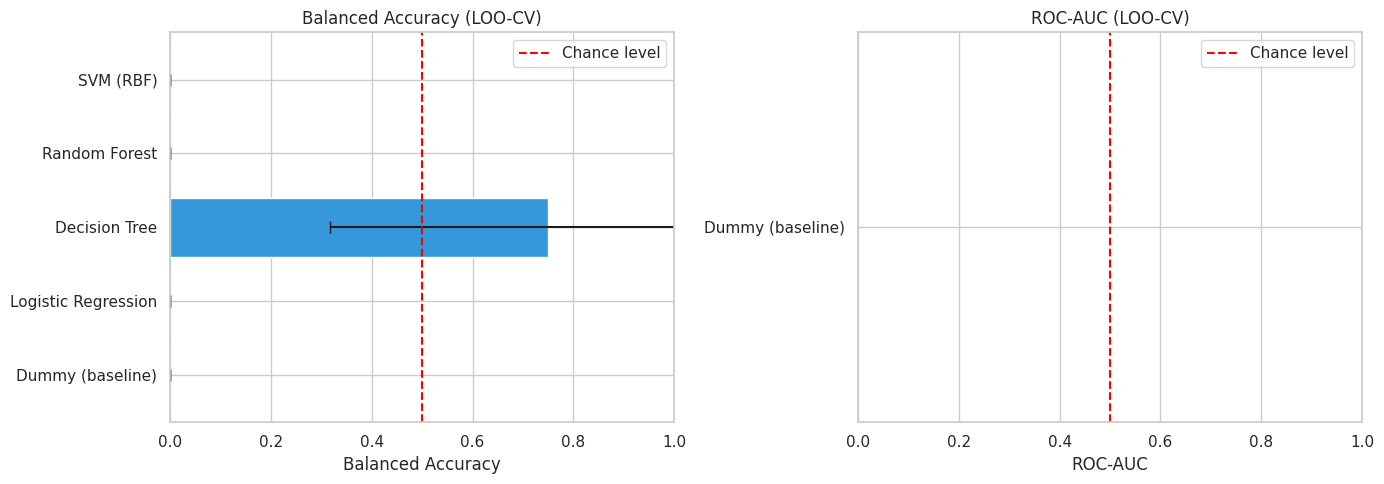

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Balanced accuracy comparison
means = summary_df['balanced_accuracy_mean']
stds  = summary_df['balanced_accuracy_std']
colors = ['#bdc3c7'] + ['#3498db'] * (len(means) - 1)  # gray for dummy

axes[0].barh(means.index, means.values, xerr=stds.values,
             color=colors, edgecolor='white', capsize=4)
axes[0].axvline(0.5, color='red', linestyle='--', label='Chance level')
axes[0].set_xlabel('Balanced Accuracy')
axes[0].set_title(f'Balanced Accuracy ({cv_name})')
axes[0].legend()
axes[0].set_xlim(0, 1)

# ROC-AUC comparison
means_roc = summary_df['roc_auc_mean']
stds_roc  = summary_df['roc_auc_std']
axes[1].barh(means_roc.index, means_roc.values, xerr=stds_roc.values,
             color=colors, edgecolor='white', capsize=4)
axes[1].axvline(0.5, color='red', linestyle='--', label='Chance level')
axes[1].set_xlabel('ROC-AUC')
axes[1].set_title(f'ROC-AUC ({cv_name})')
axes[1].legend()
axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.savefig(OUTPUTS_FIGURES / '06_model_comparison.png', dpi=150)
plt.show()

## 6. Identify best model and hyperparameter tuning

In [19]:
# Best model by balanced accuracy (exclude dummy)
non_dummy = summary_df.drop('Dummy (baseline)')
best_name = non_dummy['balanced_accuracy_mean'].idxmax()
print(f"Best model: {best_name} (balanced_accuracy={non_dummy.loc[best_name, 'balanced_accuracy_mean']:.3f})")

# Hyperparameter grids
param_grids = {
    'Logistic Regression': {
        'select__k': [5, 10, min(15, len(feature_cols))],
        'clf__C': [0.01, 0.1, 1.0, 10.0],
        'clf__penalty': ['l1', 'l2'],
        'clf__solver': ['liblinear']
    },
    'Decision Tree': {
        'select__k': [5, 10, min(15, len(feature_cols))],
        'clf__max_depth': [2, 3, 4, 5],
        'clf__min_samples_split': [2, 4]
    },
    'Random Forest': {
        'select__k': [5, 10, min(15, len(feature_cols))],
        'clf__n_estimators': [50, 100, 200],
        'clf__max_depth': [None, 3, 5]
    },
    'SVM (RBF)': {
        'select__k': [5, 10, min(15, len(feature_cols))],
        'clf__C': [0.1, 1.0, 10.0],
        'clf__gamma': ['scale', 'auto']
    }
}

if best_name in param_grids:
    print(f"\nRunning GridSearchCV for {best_name}...")
    grid_search = GridSearchCV(
        models[best_name], param_grids[best_name],
        cv=cv, scoring='balanced_accuracy',
        n_jobs=-1, refit=True
    )
    grid_search.fit(X, y)
    best_model = grid_search.best_estimator_
    print(f"Best params: {grid_search.best_params_}")
    print(f"Best CV balanced_accuracy: {grid_search.best_score_:.3f}")
else:
    best_model = models[best_name]
    best_model.fit(X, y)

Best model: Decision Tree (balanced_accuracy=0.750)

Running GridSearchCV for Decision Tree...
Best params: {'clf__max_depth': 2, 'clf__min_samples_split': 2, 'select__k': 5}
Best CV balanced_accuracy: 0.750


## 7. Permutation test (validate above-chance performance)

Running permutation test (1000 permutations)...
Model CV score:      0.750
Permutation p-value: 0.3337


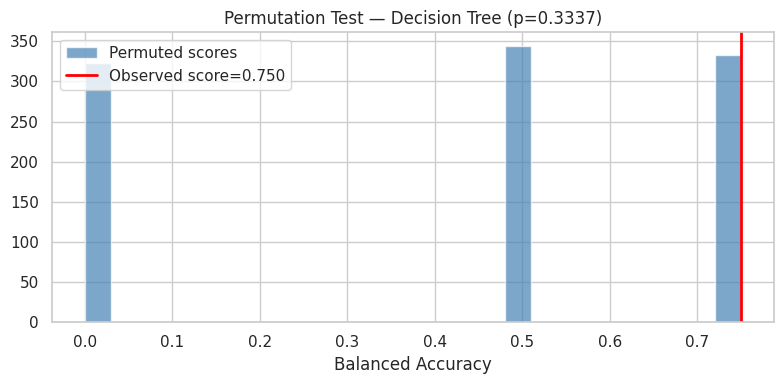

In [20]:
print("Running permutation test (1000 permutations)...")
score, perm_scores, p_value = permutation_test_score(
    best_model, X, y,
    scoring='balanced_accuracy',
    cv=cv, n_permutations=1000,
    random_state=RANDOM_STATE, n_jobs=-1
)

print(f"Model CV score:      {score:.3f}")
print(f"Permutation p-value: {p_value:.4f}")
if p_value < 0.05:
    print("Result is significant — performance is above chance.")
else:
    print("WARNING: Performance is NOT significantly above chance. Interpret results cautiously.")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(perm_scores, bins=25, color='steelblue', alpha=0.7, label='Permuted scores')
ax.axvline(score, color='red', linewidth=2, label=f'Observed score={score:.3f}')
ax.set_xlabel('Balanced Accuracy')
ax.set_title(f'Permutation Test — {best_name} (p={p_value:.4f})')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUTS_FIGURES / '06_permutation_test.png', dpi=150)
plt.show()

## 8. Confusion matrix on hold-out test set (if available)

In [21]:
if 'split' in dataset.columns and (dataset['split'] == 'test').sum() > 0:
    train_mask = dataset['split'] == 'train'
    test_mask  = dataset['split'] == 'test'

    X_train = dataset.loc[train_mask, feature_cols].values
    y_train = dataset.loc[train_mask, PERFORMANCE_LABEL_COL].astype(int).values
    X_test  = dataset.loc[test_mask,  feature_cols].values
    y_test  = dataset.loc[test_mask,  PERFORMANCE_LABEL_COL].astype(int).values

    best_model.fit(X_train, y_train)
    y_pred = best_model.predict(X_test)

    print("Classification report (hold-out test set):")
    print(classification_report(y_test, y_pred, target_names=['Low','High']))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Confusion matrix
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, display_labels=['Low','High'], ax=axes[0], colorbar=False
    )
    axes[0].set_title(f'Confusion Matrix — {best_name}')

    # ROC curve
    if hasattr(best_model, 'predict_proba'):
        y_proba = best_model.predict_proba(X_test)[:, 1]
        RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1], name=best_name)
        axes[1].plot([0,1],[0,1],'k--')
        axes[1].set_title('ROC Curve')

    plt.tight_layout()
    plt.savefig(OUTPUTS_FIGURES / '06_confusion_roc.png', dpi=150)
    plt.show()
else:
    print("No hold-out test set — cross-validation results are the primary evaluation.")

No hold-out test set — cross-validation results are the primary evaluation.


## 9. Save best model and metadata

In [22]:
# Refit on all data before saving
best_model.fit(X, y)
joblib.dump(best_model, OUTPUTS_MODELS / 'trained_model.pkl')

metadata = {
    'best_model_name':      best_name,
    'cv_strategy':          cv_name,
    'n_participants':       int(N),
    'n_features_total':     len(feature_cols),
    'k_features_selected':  int(K_FEATURES),
    'feature_col_names':    feature_cols,
    'cv_balanced_accuracy': float(score),
    'permutation_p_value':  float(p_value),
    'all_model_results':    summary_df.to_dict(),
}

with open(OUTPUTS_MODELS / 'model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"Saved: {OUTPUTS_MODELS / 'trained_model.pkl'}")
print(f"Saved: {OUTPUTS_MODELS / 'model_metadata.json'}")

Saved: /home/wlsoo/WID2003/outputs/models/trained_model.pkl
Saved: /home/wlsoo/WID2003/outputs/models/model_metadata.json
